# Stage 2b: Shortcut Auditing — Fine-tuned DistilRoBERTa

**Purpose:** Replicate all probing, SHAP, and ablation experiments from notebook `02_shortcut_auditing.ipynb`,
but using a **task-fine-tuned** `distilroberta-base` instead of the frozen pretrained weights.

The hypothesis is that fine-tuning for mental-health binary classification may amplify
shortcut-feature encoding in [CLS] relative to the baseline frozen model.

**Pipeline:**
1. Fine-tune `distilroberta-base` for sequence classification on `text → binary_label` (80/20 train/val split)
2. Save fine-tuned weights
3. Extract [CLS] embeddings from the fine-tuned encoder (encoder head only, no classifier)
4. Run identical probing, layer-wise probing, SHAP, and ablation analyses
5. Save results to `data/stage2_finetuned/` for direct comparison with `data/stage2/`

**Shortcut features (8, from Stage 1):**
`fp_singular`, `analytic`, `body_health`, `post_length`, `self_ref_rumination`,
`hedge_density`, `negative_emotion`, `emotional_feeling`

**Passed controls (2):** `cogproc`, `clout`

In [2]:
import os, json, warnings
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, r2_score)
from transformers import (
    AutoTokenizer, AutoModel, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from datasets import Dataset
import shap

sns.set_style('whitegrid')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0
print(f"Device: {DEVICE}  |  GPUs: {N_GPUS}")

# Output directory for this notebook
OUT_DIR = 'data/stage2_finetuned'
os.makedirs(OUT_DIR, exist_ok=True)
FT_MODEL_DIR = os.path.join(OUT_DIR, 'ft_model')
os.makedirs(FT_MODEL_DIR, exist_ok=True)

# ── Load Stage 1 results ─────────────────────────────────────────────────────
with open('data/stage1/stage1_results.json') as f:
    stage1 = json.load(f)

SHORTCUT_FEATURES = stage1['shortcut_features']
CONTROL_FEATURES  = stage1['passed_controls']
ALL_18_FEATURES   = stage1['all_18_features']
SHORTCUT_META     = stage1['shortcut_meta']

print(f"\nShortcut features ({len(SHORTCUT_FEATURES)}): {SHORTCUT_FEATURES}")
print(f"Control features  ({len(CONTROL_FEATURES)}): {CONTROL_FEATURES}")

Device: cuda  |  GPUs: 4

Shortcut features (8): ['fp_singular', 'analytic', 'body_health', 'post_length', 'self_ref_rumination', 'hedge_density', 'negative_emotion', 'emotional_feeling']
Control features  (2): ['cogproc', 'clout']


In [3]:
# ── Load Stage 1 data ────────────────────────────────────────────────────────
df = pd.read_pickle('data/stage1/features_18_extracted.pkl')
df['text'] = df['text'].fillna('')

GENDER_COL = 'gender_label' if 'gender_label' in df.columns else 'gender'

if 'binary_label' not in df.columns:
    df['binary_label'] = (~df['TID'].str.contains('control')).astype(int)

print(f"Loaded {len(df):,} rows")
print(f"Label distribution: {df['binary_label'].value_counts().to_dict()}")
print(f"Gender dist: {df[GENDER_COL].value_counts().to_dict()}")

mf_mask = df[GENDER_COL].isin(['male', 'female'])
df_mf = df[mf_mask].copy()
df_mf['gender_bin'] = (df_mf[GENDER_COL] == 'female').astype(int)
print(f"Male/female subset: {len(df_mf):,} rows")

Loaded 32,200 rows
Label distribution: {0: 22601, 1: 9599}
Gender dist: {'female': 16100, 'male': 16100}
Male/female subset: 32,200 rows


## Step 1 — Fine-tune DistilRoBERTa for Mental Health Classification

Fine-tune `distilroberta-base` with a sequence classification head on `text → binary_label`.

- 80 / 20 stratified train / validation split
- 3 epochs, early stopping on validation loss
- After training, only the **encoder** (no classifier head) is used for embedding extraction,
  making it directly comparable to the frozen-model analysis in notebook 02.

In [4]:
MODEL_NAME = 'distilroberta-base'
MAX_LEN    = 256
BATCH_SIZE_FT = 32
NUM_EPOCHS    = 3
LEARNING_RATE = 2e-5

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# ── Train / val split (stratified on binary_label) ───────────────────────────
train_idx, val_idx = train_test_split(
    np.arange(len(df)),
    test_size=0.2,
    random_state=42,
    stratify=df['binary_label'].values,
)
print(f"Train: {len(train_idx):,}  |  Val: {len(val_idx):,}")

def make_hf_dataset(indices):
    subset = df.iloc[indices]
    return Dataset.from_dict({
        'text':  subset['text'].tolist(),
        'label': subset['binary_label'].tolist(),
    })

train_ds = make_hf_dataset(train_idx)
val_ds   = make_hf_dataset(val_idx)

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LEN)

train_ds = train_ds.map(tokenize, batched=True, remove_columns=['text'])
val_ds   = val_ds.map(tokenize,   batched=True, remove_columns=['text'])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Dataset tokenised.")

Train: 25,760  |  Val: 6,440


Map:   0%|          | 0/25760 [00:00<?, ? examples/s]

Map:   0%|          | 0/6440 [00:00<?, ? examples/s]

Dataset tokenised.


In [5]:
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score

ft_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    ignore_mismatched_sizes=True,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs > 0.5).astype(int)
    auc = roc_auc_score(labels, probs)
    f1  = f1_score(labels, preds)
    return {'roc_auc': auc, 'f1': f1}

training_args = TrainingArguments(
    output_dir=FT_MODEL_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE_FT,
    per_device_eval_batch_size=64,
    learning_rate=LEARNING_RATE,
    weight_decay=0.01,
    warmup_ratio=0.06,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='roc_auc',
    greater_is_better=True,
    logging_steps=100,
    fp16=(DEVICE == 'cuda'),
    report_to='none',
)

trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    # tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f"Starting fine-tuning for {NUM_EPOCHS} epochs …")
trainer.train()

# Evaluate on val
val_results = trainer.evaluate()
print(f"\nValidation results: {val_results}")

# Save the full fine-tuned model
trainer.save_model(FT_MODEL_DIR)
tokenizer.save_pretrained(FT_MODEL_DIR)
print(f"Fine-tuned model saved → {FT_MODEL_DIR}")

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[RANK 0] Detected kernel v

Starting fine-tuning for 3 epochs …


Epoch,Training Loss,Validation Loss,Roc Auc,F1
1,1.976454,1.949022,0.796053,0.560144
2,1.852473,1.940960,0.803853,0.602312
3,1.804849,1.954736,0.805473,0.612107


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

RuntimeError: on_train_begin must be called before on_evaluate

In [6]:

# Save the full fine-tuned model
trainer.save_model(FT_MODEL_DIR)
tokenizer.save_pretrained(FT_MODEL_DIR)
print(f"Fine-tuned model saved → {FT_MODEL_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned model saved → data/stage2_finetuned/ft_model


## Step 2 — Extract [CLS] Embeddings from Fine-tuned Encoder

We load only the **encoder** portion (roberta body) of the fine-tuned model and extract [CLS] embeddings
for all 32,200 posts — exactly mirroring the frozen-model extraction in notebook 02.

In [7]:
BATCH_SIZE = 128

# Load the encoder (AutoModel strips the classifier head)
ft_encoder = AutoModel.from_pretrained(FT_MODEL_DIR).to(DEVICE).eval()
ft_tokenizer = AutoTokenizer.from_pretrained(FT_MODEL_DIR)

def extract_cls_embeddings(texts, model, tok, batch_size=BATCH_SIZE):
    """Extract [CLS] (first token) embeddings in batches."""
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tok(batch, truncation=True, padding=True,
                  max_length=MAX_LEN, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            out = model(**enc)
        cls_emb = out.last_hidden_state[:, 0, :].cpu().numpy()
        all_embs.append(cls_emb)
        if (i // batch_size) % 20 == 0:
            print(f"  Batch {i//batch_size + 1}/{(len(texts)-1)//batch_size + 1}", end='\r')
    print()
    return np.vstack(all_embs)

print(f"Extracting [CLS] embeddings from fine-tuned encoder for {len(df):,} posts …")
X_cls = extract_cls_embeddings(df['text'].tolist(), ft_encoder, ft_tokenizer)
print(f"Embedding shape: {X_cls.shape}")

np.save(f'{OUT_DIR}/cls_embeddings_finetuned.npy', X_cls)
print(f"Saved → {OUT_DIR}/cls_embeddings_finetuned.npy")

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: data/stage2_finetuned/ft_model
Key                        | Status     | 
---------------------------+------------+-
classifier.dense.bias      | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.out_proj.bias   | UNEXPECTED | 
classifier.dense.weight    | UNEXPECTED | 
pooler.dense.weight        | MISSING    | 
pooler.dense.bias          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Extracting [CLS] embeddings from fine-tuned encoder for 32,200 posts …
  Batch 241/252
Embedding shape: (32200, 768)
Saved → data/stage2_finetuned/cls_embeddings_finetuned.npy


## 2A — Probing Classifiers on Fine-tuned [CLS] Embeddings

Identical methodology to notebook 02, but probing the **fine-tuned** [CLS] representations.

If shortcuts are more strongly encoded after fine-tuning (higher AUC / R²), it suggests the model
learned to leverage gender-correlated style features during task training.

In [8]:
scaler = StandardScaler()
X_cls_scaled = scaler.fit_transform(X_cls)

probe_results = []
PROBE_FEATURES = SHORTCUT_FEATURES + CONTROL_FEATURES

for feat in PROBE_FEATURES:
    y_cont = df[feat].fillna(0).values.astype(float)
    role = 'shortcut' if feat in SHORTCUT_FEATURES else 'control'

    # (a) Regression probe: Ridge → R²
    ridge = Ridge(alpha=1.0)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_strat = df['binary_label'].values
    r2_scores = []
    for train_ix, test_ix in cv.split(X_cls_scaled, y_strat):
        ridge.fit(X_cls_scaled[train_ix], y_cont[train_ix])
        y_hat = ridge.predict(X_cls_scaled[test_ix])
        r2_scores.append(r2_score(y_cont[test_ix], y_hat))
    r2_mean = np.mean(r2_scores)

    # (b) Classification probe: above/below median → AUC
    median_val = np.median(y_cont)
    y_bin = (y_cont > median_val).astype(int)
    clf = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
    cv_cls = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = cross_val_score(clf, X_cls_scaled, y_bin, cv=cv_cls, scoring='roc_auc')

    probe_results.append({
        'feature': feat,
        'role': role,
        'probe_R2': r2_mean,
        'probe_AUC_median_split': aucs.mean(),
        'probe_AUC_std': aucs.std(),
    })
    print(f"  [{role:8s}] {feat:22s}  R²={r2_mean:.4f}  AUC(med-split)={aucs.mean():.3f}±{aucs.std():.3f}")

# Gender probe
mf_idx = df.index[mf_mask].tolist()
X_mf = X_cls_scaled[mf_idx]
y_gender = df_mf['gender_bin'].values
clf_g = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
aucs_g = cross_val_score(clf_g, X_mf, y_gender,
                          cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                          scoring='roc_auc')
print(f"\n  {'gender (m/f)':22s}  AUC={aucs_g.mean():.3f}±{aucs_g.std():.3f}")

# Label probe
y_label = df['binary_label'].values
clf_l = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
aucs_l = cross_val_score(clf_l, X_cls_scaled, y_label,
                          cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                          scoring='roc_auc')
print(f"  {'binary_label':22s}  AUC={aucs_l.mean():.3f}±{aucs_l.std():.3f}")

probe_df = pd.DataFrame(probe_results)
probe_df

  [shortcut] fp_singular             R²=0.7756  AUC(med-split)=0.954±0.002
  [shortcut] analytic                R²=0.6033  AUC(med-split)=0.886±0.003
  [shortcut] body_health             R²=0.6200  AUC(med-split)=0.868±0.002
  [shortcut] post_length             R²=0.3802  AUC(med-split)=0.995±0.000
  [shortcut] self_ref_rumination     R²=0.2947  AUC(med-split)=0.892±0.004
  [shortcut] hedge_density           R²=0.3061  AUC(med-split)=0.781±0.003
  [shortcut] negative_emotion        R²=0.2656  AUC(med-split)=0.877±0.003
  [shortcut] emotional_feeling       R²=0.4107  AUC(med-split)=0.820±0.007
  [control ] cogproc                 R²=0.5428  AUC(med-split)=0.840±0.003
  [control ] clout                   R²=0.5505  AUC(med-split)=0.894±0.004

  gender (m/f)            AUC=0.984±0.002
  binary_label            AUC=0.833±0.003


,feature,role,probe_R2,probe_AUC_median_split,probe_AUC_std
0,fp_singular,shortcut,0.775567,0.954373,0.001732
1,analytic,shortcut,0.603347,0.886273,0.003483
2,body_health,shortcut,0.619989,0.867898,0.002458
3,post_length,shortcut,0.380204,0.995139,0.000246
4,self_ref_rumination,shortcut,0.294676,0.892424,0.004277
5,hedge_density,shortcut,0.306149,0.780941,0.003340
6,negative_emotion,shortcut,0.265573,0.876513,0.002608
7,emotional_feeling,shortcut,0.410672,0.820007,0.006977
8,cogproc,control,0.542802,0.839765,0.002976
9,clout,control,0.550489,0.893686,0.003826


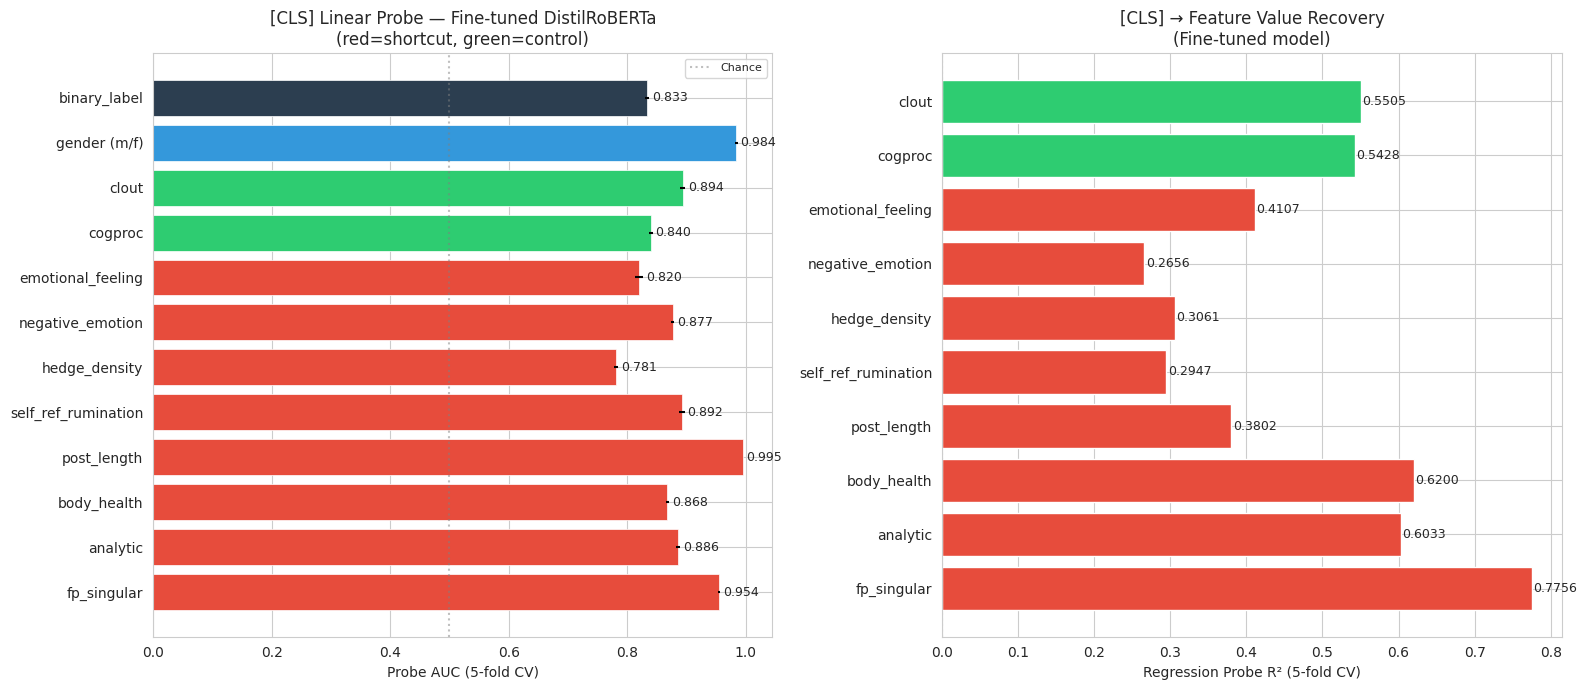

Saved → data/stage2_finetuned/probing_results_finetuned.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

probe_labels = PROBE_FEATURES + ['gender (m/f)', 'binary_label']
probe_aucs   = [probe_df.loc[probe_df['feature']==f, 'probe_AUC_median_split'].values[0]
                for f in PROBE_FEATURES] + [aucs_g.mean(), aucs_l.mean()]
probe_stds   = [probe_df.loc[probe_df['feature']==f, 'probe_AUC_std'].values[0]
                for f in PROBE_FEATURES] + [aucs_g.std(), aucs_l.std()]
colors = (['#e74c3c'] * len(SHORTCUT_FEATURES) +
          ['#2ecc71'] * len(CONTROL_FEATURES) +
          ['#3498db', '#2c3e50'])

axes[0].barh(range(len(probe_labels)), probe_aucs, xerr=probe_stds,
             color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_yticks(range(len(probe_labels)))
axes[0].set_yticklabels(probe_labels, fontsize=10)
axes[0].axvline(0.5, color='grey', linestyle=':', alpha=0.5, label='Chance')
axes[0].set_xlabel('Probe AUC (5-fold CV)')
axes[0].set_title('[CLS] Linear Probe — Fine-tuned DistilRoBERTa\n(red=shortcut, green=control)')
axes[0].legend(fontsize=8)
for i, (auc, std) in enumerate(zip(probe_aucs, probe_stds)):
    axes[0].text(auc + std + 0.005, i, f'{auc:.3f}', va='center', fontsize=9)

r2_vals = probe_df['probe_R2'].values
r2_colors = (['#e74c3c'] * len(SHORTCUT_FEATURES) + ['#2ecc71'] * len(CONTROL_FEATURES))
axes[1].barh(range(len(PROBE_FEATURES)), r2_vals, color=r2_colors, edgecolor='white')
axes[1].set_yticks(range(len(PROBE_FEATURES)))
axes[1].set_yticklabels(PROBE_FEATURES, fontsize=10)
axes[1].axvline(0, color='grey', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Regression Probe R² (5-fold CV)')
axes[1].set_title('[CLS] → Feature Value Recovery\n(Fine-tuned model)')
for i, r2 in enumerate(r2_vals):
    axes[1].text(max(r2, 0) + 0.002, i, f'{r2:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/probing_results_finetuned.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {OUT_DIR}/probing_results_finetuned.png")

## 2A′ — Layer-wise Probing: Fine-tuned Model Depth

Same layer-wise probing as notebook 02 but for the fine-tuned model.
Expect shortcut features (especially those correlated with the task label) to become
separable earlier or more strongly after fine-tuning.

In [10]:
def extract_cls_all_layers(texts, model, tok, batch_size=128, max_len=256):
    """Extract [CLS] from every layer (embedding + 6 transformer layers)."""
    n_layers = model.config.num_hidden_layers
    layer_embs = [[] for _ in range(n_layers + 1)]

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tok(batch, truncation=True, padding=True,
                  max_length=max_len, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            out = model(**enc, output_hidden_states=True)
        for layer_idx in range(n_layers + 1):
            cls_vec = out.hidden_states[layer_idx][:, 0, :].cpu().numpy()
            layer_embs[layer_idx].append(cls_vec)
        if (i // batch_size) % 25 == 0:
            print(f"  Batch {i//batch_size+1}/{(len(texts)-1)//batch_size+1}", end='\r')

    print()
    return [np.vstack(le) for le in layer_embs]

print(f"Extracting all-layer [CLS] from fine-tuned encoder for {len(df):,} posts …")
all_layer_cls = extract_cls_all_layers(df['text'].tolist(), ft_encoder, ft_tokenizer)
n_layers = len(all_layer_cls)
layer_names = ['Emb'] + [f'L{i}' for i in range(1, n_layers)]
print(f"Got {n_layers} layers, each shape {all_layer_cls[0].shape}")

Extracting all-layer [CLS] from fine-tuned encoder for 32,200 posts …
  Batch 251/252
Got 7 layers, each shape (32200, 768)


In [11]:
from sklearn.preprocessing import StandardScaler as SS
from sklearn.metrics import roc_auc_score

PROBE_TARGETS = SHORTCUT_FEATURES + CONTROL_FEATURES

# Binary targets (above/below median for features; actual binary for gender/label)
targets = {}
for feat in PROBE_TARGETS:
    vals = df[feat].fillna(0).values.astype(float)
    targets[feat] = (vals > np.median(vals)).astype(int)

mf_idx_arr = np.where(df[GENDER_COL].isin(['male', 'female']).values)[0]
targets['gender'] = (df.iloc[mf_idx_arr][GENDER_COL] == 'female').astype(int).values
targets['binary_label'] = df['binary_label'].values.astype(int)

def gpu_probe_auc(X_np, y_np, n_splits=5, lr=0.01, epochs=200, batch_size=2048):
    """Train logistic regression on GPU, return mean AUC across folds."""
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    aucs = []
    for tr_idx, te_idx in cv.split(X_np, y_np):
        X_tr = torch.tensor(X_np[tr_idx], dtype=torch.float32, device=DEVICE)
        y_tr = torch.tensor(y_np[tr_idx], dtype=torch.float32, device=DEVICE)
        X_te = torch.tensor(X_np[te_idx], dtype=torch.float32, device=DEVICE)
        y_te = y_np[te_idx]

        model_p = nn.Linear(X_tr.shape[1], 1).to(DEVICE)
        opt = torch.optim.Adam(model_p.parameters(), lr=lr, weight_decay=1e-4)
        loss_fn = nn.BCEWithLogitsLoss()

        model_p.train()
        n = len(X_tr)
        for epoch in range(epochs):
            perm = torch.randperm(n, device=DEVICE)
            for start in range(0, n, batch_size):
                idx = perm[start:start+batch_size]
                logits = model_p(X_tr[idx]).squeeze(-1)
                loss = loss_fn(logits, y_tr[idx])
                opt.zero_grad(); loss.backward(); opt.step()

        model_p.eval()
        with torch.no_grad():
            probs = torch.sigmoid(model_p(X_te).squeeze(-1)).cpu().numpy()
        aucs.append(roc_auc_score(y_te, probs))
    return np.mean(aucs), np.std(aucs)

lw_results = []
for layer_idx in range(n_layers):
    X_layer = all_layer_cls[layer_idx]
    X_scaled = SS().fit_transform(X_layer)

    for target_name, y in targets.items():
        X_probe = X_scaled[mf_idx_arr] if target_name == 'gender' else X_scaled
        auc_mean, auc_std = gpu_probe_auc(X_probe, y)
        role = ('shortcut' if target_name in SHORTCUT_FEATURES
                else 'control' if target_name in CONTROL_FEATURES
                else 'meta')
        lw_results.append({
            'layer': layer_idx, 'layer_name': layer_names[layer_idx],
            'target': target_name, 'role': role,
            'AUC': auc_mean, 'AUC_std': auc_std,
        })

    print(f"  Layer {layer_names[layer_idx]:3s} done")

layer_probe_df = pd.DataFrame(lw_results)
pivot = layer_probe_df.pivot(index='target', columns='layer_name', values='AUC')[layer_names]
print("\nLayer-wise probing AUC:")
print(pivot.round(3).to_string())

  Layer Emb done
  Layer L1  done
  Layer L2  done
  Layer L3  done
  Layer L4  done
  Layer L5  done
  Layer L6  done

Layer-wise probing AUC:
layer_name           Emb     L1     L2     L3     L4     L5     L6
target                                                            
analytic             0.5  0.967  0.965  0.959  0.944  0.918  0.883
binary_label         0.5  0.781  0.794  0.808  0.819  0.827  0.830
body_health          0.5  0.878  0.879  0.879  0.870  0.876  0.866
clout                0.5  0.935  0.935  0.933  0.923  0.904  0.889
cogproc              0.5  0.906  0.910  0.902  0.890  0.868  0.837
emotional_feeling    0.5  0.859  0.870  0.865  0.857  0.847  0.816
fp_singular          0.5  0.976  0.973  0.973  0.969  0.961  0.953
gender               0.5  0.951  0.951  0.964  0.969  0.979  0.984
hedge_density        0.5  0.856  0.866  0.850  0.827  0.803  0.775
negative_emotion     0.5  0.892  0.895  0.899  0.893  0.889  0.874
post_length          0.5  1.000  1.000  0.999  0.999

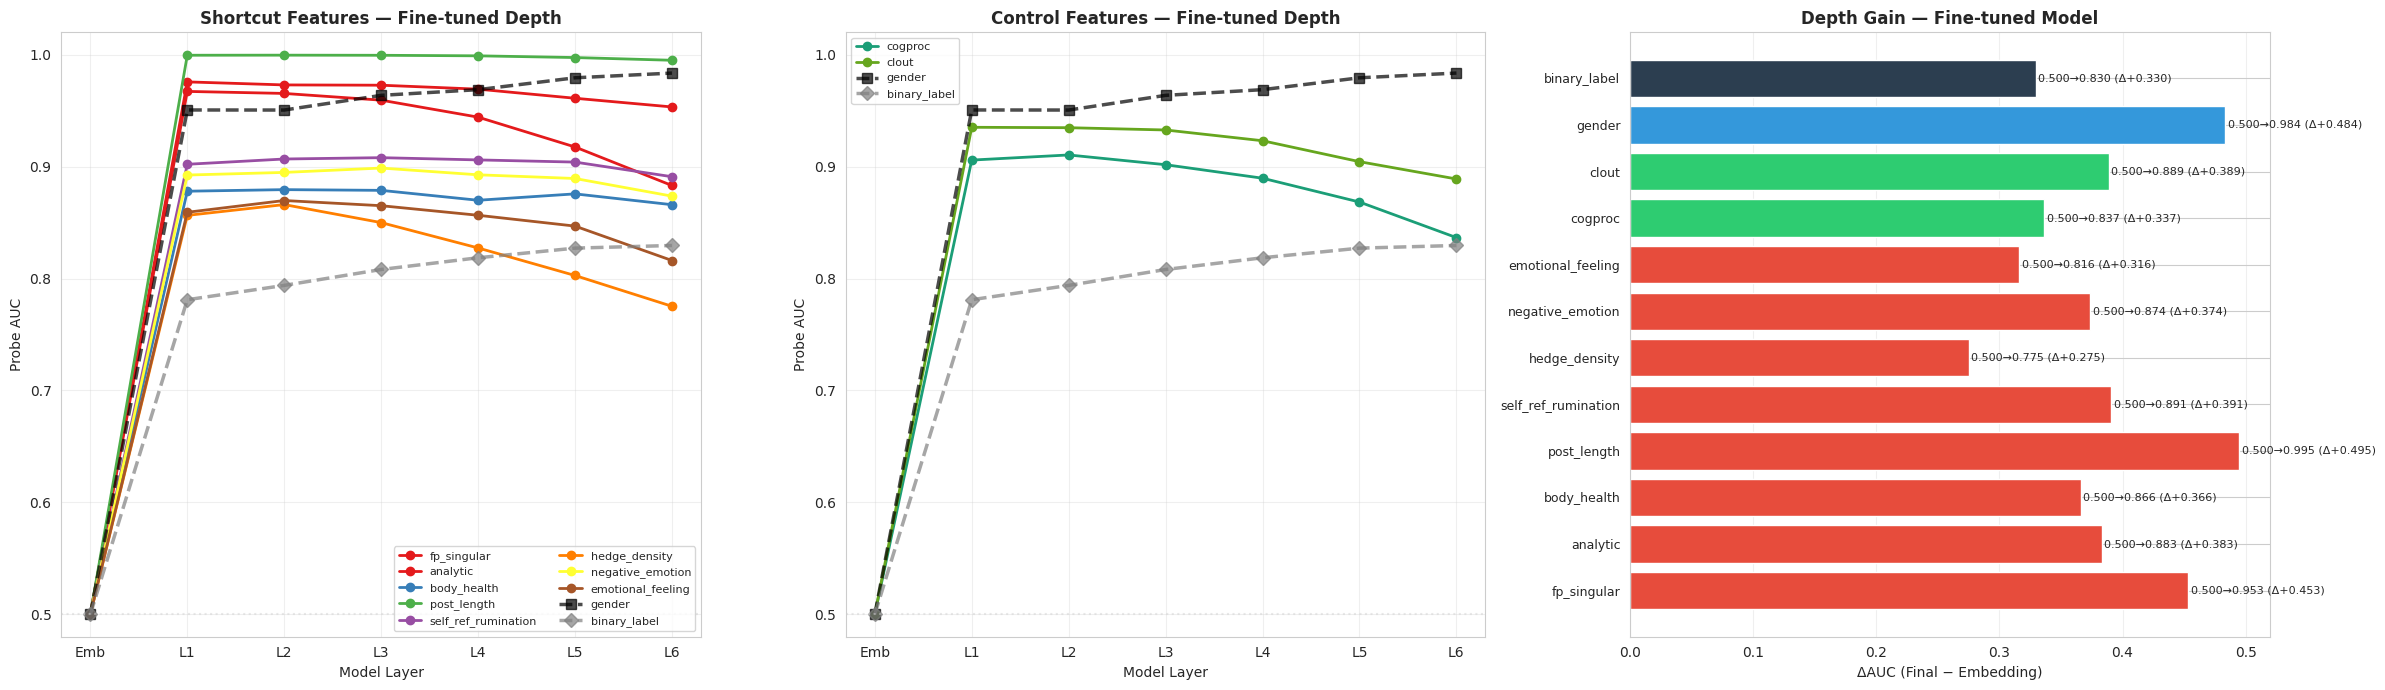

Saved → data/stage2_finetuned/layerwise_probing_finetuned.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
layers_x = np.arange(n_layers)

# (A) Shortcut features
cmap_sc = plt.cm.Set1(np.linspace(0, 0.7, len(SHORTCUT_FEATURES)))
for i, feat in enumerate(SHORTCUT_FEATURES):
    row = layer_probe_df[layer_probe_df['target']==feat].sort_values('layer')
    axes[0].plot(layers_x, row['AUC'].values, 'o-', color=cmap_sc[i],
                 label=feat, linewidth=2, markersize=6)
row_g = layer_probe_df[layer_probe_df['target']=='gender'].sort_values('layer')
row_l = layer_probe_df[layer_probe_df['target']=='binary_label'].sort_values('layer')
axes[0].plot(layers_x, row_g['AUC'].values, 's--', color='black', label='gender',
             linewidth=2.5, markersize=7, alpha=0.7)
axes[0].plot(layers_x, row_l['AUC'].values, 'D--', color='grey', label='binary_label',
             linewidth=2.5, markersize=7, alpha=0.7)
axes[0].axhline(0.5, color='lightgrey', linestyle=':', alpha=0.5)
axes[0].set_xticks(layers_x); axes[0].set_xticklabels(layer_names)
axes[0].set_xlabel('Model Layer'); axes[0].set_ylabel('Probe AUC')
axes[0].set_title('Shortcut Features — Fine-tuned Depth', fontweight='bold')
axes[0].legend(fontsize=8, ncol=2); axes[0].set_ylim(0.48, 1.02); axes[0].grid(alpha=0.3)

# (B) Control features
cmap_ctrl = plt.cm.Dark2(np.linspace(0, 0.6, len(CONTROL_FEATURES)))
for i, feat in enumerate(CONTROL_FEATURES):
    row = layer_probe_df[layer_probe_df['target']==feat].sort_values('layer')
    axes[1].plot(layers_x, row['AUC'].values, 'o-', color=cmap_ctrl[i],
                 label=feat, linewidth=2, markersize=6)
axes[1].plot(layers_x, row_g['AUC'].values, 's--', color='black', label='gender',
             linewidth=2.5, markersize=7, alpha=0.7)
axes[1].plot(layers_x, row_l['AUC'].values, 'D--', color='grey', label='binary_label',
             linewidth=2.5, markersize=7, alpha=0.7)
axes[1].axhline(0.5, color='lightgrey', linestyle=':', alpha=0.5)
axes[1].set_xticks(layers_x); axes[1].set_xticklabels(layer_names)
axes[1].set_xlabel('Model Layer'); axes[1].set_ylabel('Probe AUC')
axes[1].set_title('Control Features — Fine-tuned Depth', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].set_ylim(0.48, 1.02); axes[1].grid(alpha=0.3)

# (C) Δ AUC: Emb → final layer
all_targets_ordered = SHORTCUT_FEATURES + CONTROL_FEATURES + ['gender', 'binary_label']
deltas, auc_emb_list, auc_final_list = [], [], []
for t in all_targets_ordered:
    row = layer_probe_df[layer_probe_df['target']==t].sort_values('layer')
    deltas.append(row['AUC'].values[-1] - row['AUC'].values[0])
    auc_emb_list.append(row['AUC'].values[0])
    auc_final_list.append(row['AUC'].values[-1])

bar_colors = (['#e74c3c']*len(SHORTCUT_FEATURES) + ['#2ecc71']*len(CONTROL_FEATURES)
              + ['#3498db', '#2c3e50'])
axes[2].barh(range(len(all_targets_ordered)), deltas, color=bar_colors, edgecolor='white')
axes[2].set_yticks(range(len(all_targets_ordered)))
axes[2].set_yticklabels(all_targets_ordered, fontsize=9)
axes[2].axvline(0, color='grey', linewidth=0.5)
axes[2].set_xlabel('ΔAUC (Final − Embedding)')
axes[2].set_title('Depth Gain — Fine-tuned Model', fontweight='bold')
for i, (d, ae, af) in enumerate(zip(deltas, auc_emb_list, auc_final_list)):
    axes[2].text(max(d, 0)+0.002, i, f'{ae:.3f}→{af:.3f} (Δ{d:+.3f})', va='center', fontsize=8)
axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/layerwise_probing_finetuned.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {OUT_DIR}/layerwise_probing_finetuned.png")

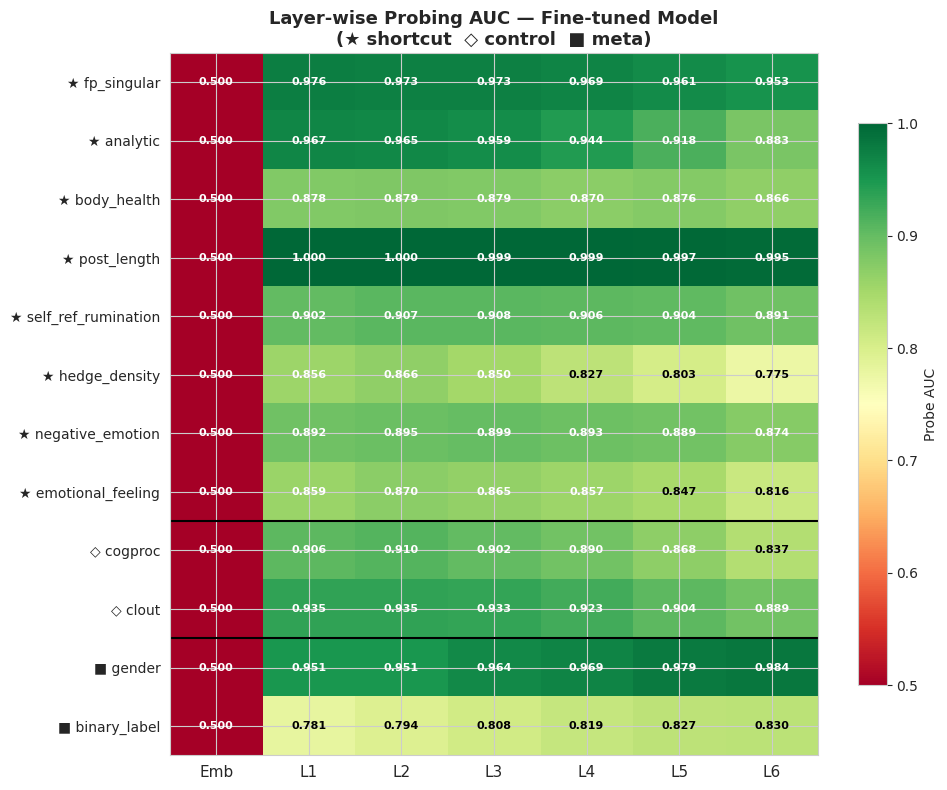

Saved → data/stage2_finetuned/layerwise_heatmap_finetuned.png


In [13]:
# Layer × feature AUC heatmap
heatmap_data = layer_probe_df.pivot(index='target', columns='layer_name', values='AUC')
heatmap_data = heatmap_data.loc[all_targets_ordered, layer_names]

row_labels = ([f'★ {f}' for f in SHORTCUT_FEATURES] +
              [f'◇ {f}' for f in CONTROL_FEATURES] +
              ['■ gender', '■ binary_label'])

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=0.5, vmax=1.0)
ax.set_xticks(range(n_layers)); ax.set_xticklabels(layer_names, fontsize=11)
ax.set_yticks(range(len(all_targets_ordered)))
ax.set_yticklabels(row_labels, fontsize=10)
ax.set_title('Layer-wise Probing AUC — Fine-tuned Model\n(★ shortcut  ◇ control  ■ meta)',
             fontsize=13, fontweight='bold')
for i in range(len(all_targets_ordered)):
    for j in range(n_layers):
        val = heatmap_data.values[i, j]
        color = 'white' if val > 0.85 or val < 0.55 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=8,
                color=color, fontweight='bold')
ax.axhline(len(SHORTCUT_FEATURES) - 0.5, color='black', linewidth=1.5)
ax.axhline(len(SHORTCUT_FEATURES) + len(CONTROL_FEATURES) - 0.5, color='black', linewidth=1.5)
plt.colorbar(im, ax=ax, label='Probe AUC', shrink=0.8)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/layerwise_heatmap_finetuned.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {OUT_DIR}/layerwise_heatmap_finetuned.png")
layer_probe_df.to_csv(f'{OUT_DIR}/stage2b_layerwise_probing.csv', index=False)

## 2B — SHAP Token Attribution (Fine-tuned Model)

Identical SHAP analysis on the 8 shortcut features.
Logistic regression is trained on raw LIWC features (not embeddings) — the SHAP values reflect
how the shortcut features drive the label, unchanged from notebook 02.
This section is included for self-contained reproducibility.

In [14]:
X_short = df[SHORTCUT_FEATURES].fillna(0).values.astype(float)
y_label = df['binary_label'].values.astype(int)

sc = StandardScaler()
X_short_scaled = sc.fit_transform(X_short)

clf_shap = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
clf_shap.fit(X_short_scaled, y_label)
auc_short = roc_auc_score(y_label, clf_shap.predict_proba(X_short_scaled)[:, 1])
print(f"{len(SHORTCUT_FEATURES)}-shortcut logistic model AUC (train): {auc_short:.4f}")

explainer = shap.LinearExplainer(clf_shap, X_short_scaled, feature_names=SHORTCUT_FEATURES)
shap_values = explainer.shap_values(X_short_scaled)
mean_abs_shap = np.abs(shap_values).mean(axis=0)

print("\nMean |SHAP| per feature:")
for feat, val in sorted(zip(SHORTCUT_FEATURES, mean_abs_shap), key=lambda x: -x[1]):
    print(f"  {feat:25s}: {val:.4f}")

8-shortcut logistic model AUC (train): 0.7123

Mean |SHAP| per feature:
  analytic                 : 0.3204
  fp_singular              : 0.2317
  body_health              : 0.1899
  negative_emotion         : 0.1127
  post_length              : 0.0944
  emotional_feeling        : 0.0347
  hedge_density            : 0.0180
  self_ref_rumination      : 0.0090


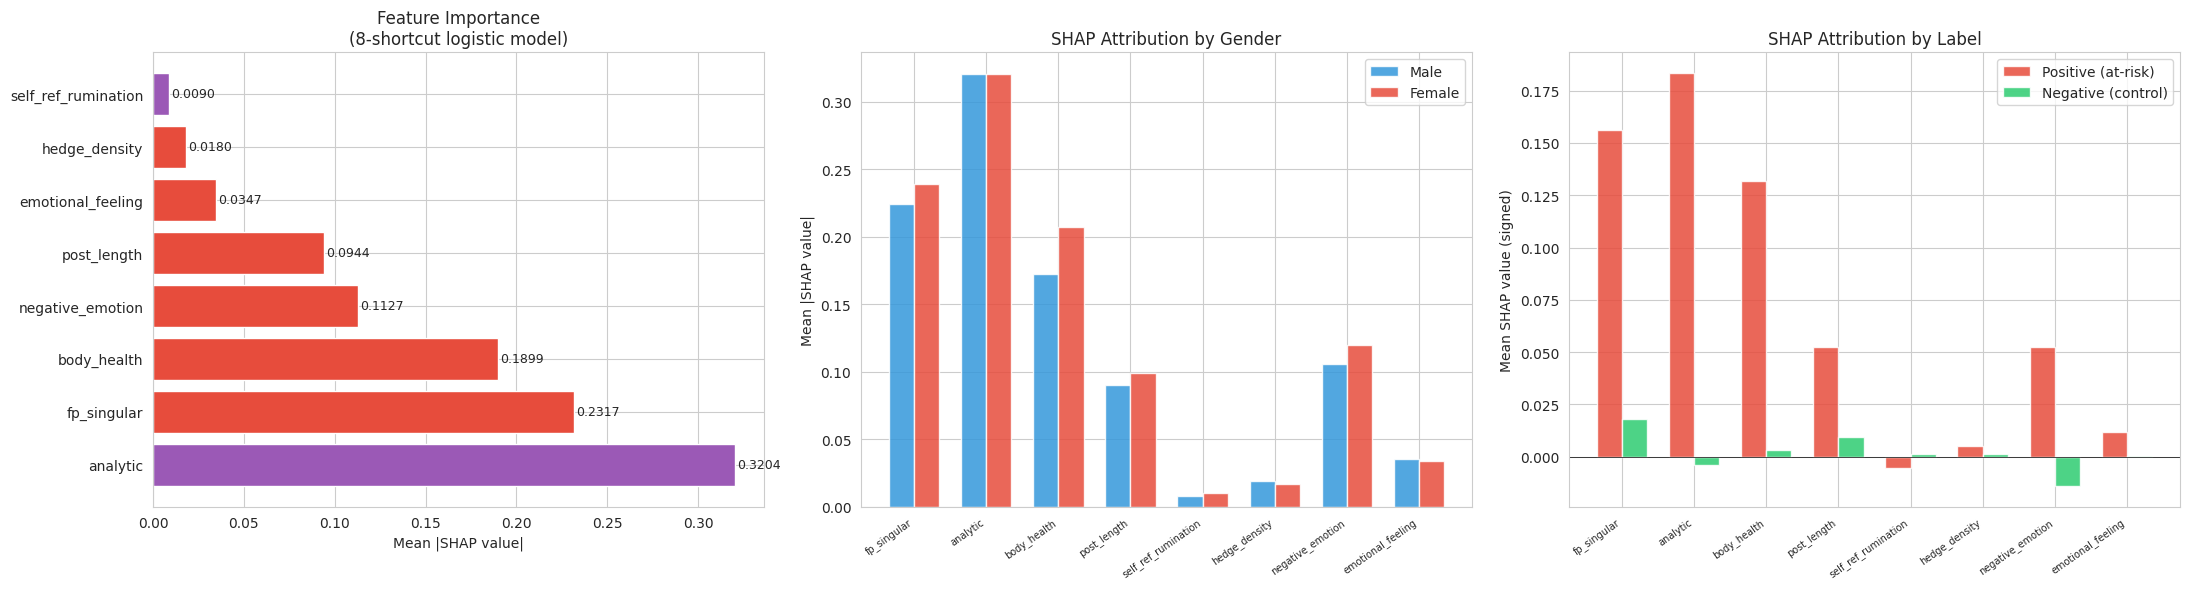

Saved → data/stage2_finetuned/shap_shortcut_analysis_finetuned.png


In [15]:
n_short = len(SHORTCUT_FEATURES)
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

mean_abs = np.abs(shap_values).mean(axis=0)
order = np.argsort(mean_abs)[::-1]
bar_colors = []
for i in order:
    feat = SHORTCUT_FEATURES[i]
    bar_colors.append('#9b59b6' if SHORTCUT_META[feat].get('was_control', False) else '#e74c3c')

axes[0].barh(range(len(order)), mean_abs[order], color=bar_colors, edgecolor='white')
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels([SHORTCUT_FEATURES[i] for i in order], fontsize=10)
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title(f'Feature Importance\n(8-shortcut logistic model)')
for i, idx in enumerate(order):
    axes[0].text(mean_abs[idx]+0.001, i, f'{mean_abs[idx]:.4f}', va='center', fontsize=9)

shap_df = pd.DataFrame(shap_values, columns=SHORTCUT_FEATURES)
shap_df['gender'] = df[GENDER_COL].values
male_shap   = shap_df[shap_df['gender']=='male'][SHORTCUT_FEATURES].abs().mean()
female_shap = shap_df[shap_df['gender']=='female'][SHORTCUT_FEATURES].abs().mean()

x = np.arange(n_short); w = 0.35
axes[1].bar(x-w/2, male_shap.values,   w, label='Male',   color='#3498db', alpha=0.85)
axes[1].bar(x+w/2, female_shap.values, w, label='Female', color='#e74c3c', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(SHORTCUT_FEATURES, fontsize=7, rotation=35, ha='right')
axes[1].set_ylabel('Mean |SHAP value|')
axes[1].set_title('SHAP Attribution by Gender'); axes[1].legend()

pos_shap = shap_df[df['binary_label'].values==1][SHORTCUT_FEATURES].mean()
neg_shap = shap_df[df['binary_label'].values==0][SHORTCUT_FEATURES].mean()
axes[2].bar(x-w/2, pos_shap.values, w, label='Positive (at-risk)', color='#e74c3c', alpha=0.85)
axes[2].bar(x+w/2, neg_shap.values, w, label='Negative (control)', color='#2ecc71', alpha=0.85)
axes[2].set_xticks(x); axes[2].set_xticklabels(SHORTCUT_FEATURES, fontsize=7, rotation=35, ha='right')
axes[2].set_ylabel('Mean SHAP value (signed)')
axes[2].set_title('SHAP Attribution by Label'); axes[2].axhline(0, color='black', linewidth=0.5); axes[2].legend()

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/shap_shortcut_analysis_finetuned.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {OUT_DIR}/shap_shortcut_analysis_finetuned.png")

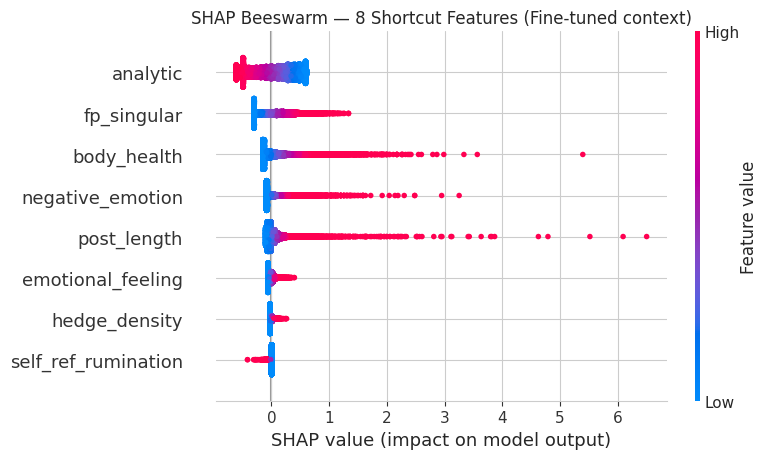

Saved → data/stage2_finetuned/shap_beeswarm_finetuned.png


In [16]:
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=np.full(len(shap_values), explainer.expected_value),
    data=X_short_scaled,
    feature_names=SHORTCUT_FEATURES,
)
fig, ax = plt.subplots(figsize=(12, 6))
shap.plots.beeswarm(shap_explanation, show=False, max_display=len(SHORTCUT_FEATURES))
plt.title('SHAP Beeswarm — 8 Shortcut Features (Fine-tuned context)')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/shap_beeswarm_finetuned.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {OUT_DIR}/shap_beeswarm_finetuned.png")

## 2C — Feature Ablation on Fine-tuned [CLS] Embeddings

Here we measure the reliance of a **linear probe trained on fine-tuned embeddings** on each shortcut feature.

Unlike notebook 02's ablation (which zeroed out raw LIWC features in a logistic model), here we:
1. Train a linear classifier on fine-tuned [CLS] embeddings predicting `binary_label` (as a proxy for the fine-tuned model's task signal)
2. Separately ablate each shortcut from the **raw feature matrix** (same 18-feature logistic setup as notebook 02) for direct comparison

Both ablation results are saved.

In [17]:
# ── Ablation on raw 18-feature logistic model (identical to notebook 02) ─────
X_all = df[ALL_18_FEATURES].fillna(0).values.astype(float)
y_all = df['binary_label'].values.astype(int)

sc18 = StandardScaler()
X_all_scaled = sc18.fit_transform(X_all)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf_base = LogisticRegression(max_iter=1000, random_state=42)
base_aucs = cross_val_score(clf_base, X_all_scaled, y_all, cv=cv, scoring='roc_auc')
baseline_auc = base_aucs.mean()
print(f"Baseline (18 raw features): AUC = {baseline_auc:.4f} ± {base_aucs.std():.4f}")

ablation_results = []
for feat in SHORTCUT_FEATURES:
    feat_idx = ALL_18_FEATURES.index(feat)
    X_abl = X_all_scaled.copy()
    X_abl[:, feat_idx] = 0
    clf_abl = LogisticRegression(max_iter=1000, random_state=42)
    abl_aucs = cross_val_score(clf_abl, X_abl, y_all, cv=cv, scoring='roc_auc')
    drop = baseline_auc - abl_aucs.mean()
    ablation_results.append({
        'ablated': feat, 'AUC_after': abl_aucs.mean(),
        'AUC_std': abl_aucs.std(), 'AUC_drop': drop,
        'drop_pct': drop / baseline_auc * 100,
    })
    print(f"  Ablate {feat:25s}: AUC = {abl_aucs.mean():.4f}  (Δ = {drop:+.4f})")

feat_idxs = [ALL_18_FEATURES.index(f) for f in SHORTCUT_FEATURES]
X_abl_all = X_all_scaled.copy(); X_abl_all[:, feat_idxs] = 0
abl_all_aucs = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                                X_abl_all, y_all, cv=cv, scoring='roc_auc')
drop_all = baseline_auc - abl_all_aucs.mean()
print(f"\n  Ablate ALL {len(SHORTCUT_FEATURES)} shortcuts: AUC = {abl_all_aucs.mean():.4f}  (Δ = {drop_all:+.4f})")

ablation_df = pd.DataFrame(ablation_results)
ablation_df

Baseline (18 raw features): AUC = 0.7214 ± 0.0074
  Ablate fp_singular              : AUC = 0.7166  (Δ = +0.0049)
  Ablate analytic                 : AUC = 0.7186  (Δ = +0.0028)
  Ablate body_health              : AUC = 0.7032  (Δ = +0.0182)
  Ablate post_length              : AUC = 0.7173  (Δ = +0.0041)
  Ablate self_ref_rumination      : AUC = 0.7215  (Δ = -0.0000)
  Ablate hedge_density            : AUC = 0.7215  (Δ = -0.0001)
  Ablate negative_emotion         : AUC = 0.7208  (Δ = +0.0006)
  Ablate emotional_feeling        : AUC = 0.7214  (Δ = -0.0000)

  Ablate ALL 8 shortcuts: AUC = 0.6503  (Δ = +0.0711)


,ablated,AUC_after,AUC_std,AUC_drop,drop_pct
0,fp_singular,0.716560,0.008243,0.004857,0.673260
1,analytic,0.718633,0.007361,0.002784,0.385926
2,body_health,0.703240,0.005938,0.018176,2.519555
3,post_length,0.717294,0.007624,0.004123,0.571505
4,self_ref_rumination,0.721459,0.007360,-0.000042,-0.005855
5,hedge_density,0.721535,0.007457,-0.000119,-0.016458
6,negative_emotion,0.720826,0.007283,0.000590,0.081829
7,emotional_feeling,0.721434,0.007421,-0.000017,-0.002387


In [18]:
# ── Gender-stratified ablation ────────────────────────────────────────────────
clf_full = LogisticRegression(max_iter=1000, random_state=42)
clf_full.fit(X_all_scaled, y_all)
genders = df[GENDER_COL].values

strat_results = []
for gender in ['male', 'female']:
    g_mask = genders == gender
    X_g = X_all_scaled[g_mask]; y_g = y_all[g_mask]
    if len(np.unique(y_g)) < 2: continue
    base_auc_g = roc_auc_score(y_g, clf_full.predict_proba(X_g)[:, 1])

    for feat in SHORTCUT_FEATURES:
        feat_idx = ALL_18_FEATURES.index(feat)
        X_g_abl = X_g.copy(); X_g_abl[:, feat_idx] = 0
        abl_auc_g = roc_auc_score(y_g, clf_full.predict_proba(X_g_abl)[:, 1])
        drop_g = base_auc_g - abl_auc_g
        strat_results.append({
            'gender': gender, 'ablated': feat, 'n_posts': g_mask.sum(),
            'baseline_AUC': base_auc_g, 'ablated_AUC': abl_auc_g,
            'AUC_drop': drop_g, 'drop_pct': drop_g / base_auc_g * 100,
        })

strat_df = pd.DataFrame(strat_results)
pivot_abl = strat_df.pivot(index='ablated', columns='gender', values='AUC_drop')
pivot_abl['asymmetry'] = (pivot_abl['male'] - pivot_abl['female']).abs()
print("Gender-stratified ablation (AUC drop):")
print(pivot_abl.round(4).to_string())

Gender-stratified ablation (AUC drop):
gender               female    male  asymmetry
ablated                                       
analytic             0.0022 -0.0002     0.0024
body_health          0.0244  0.0142     0.0102
emotional_feeling   -0.0000  0.0003     0.0003
fp_singular          0.0054  0.0038     0.0016
hedge_density        0.0000 -0.0000     0.0000
negative_emotion     0.0049  0.0031     0.0018
post_length          0.0024  0.0060     0.0037
self_ref_rumination  0.0000  0.0000     0.0000


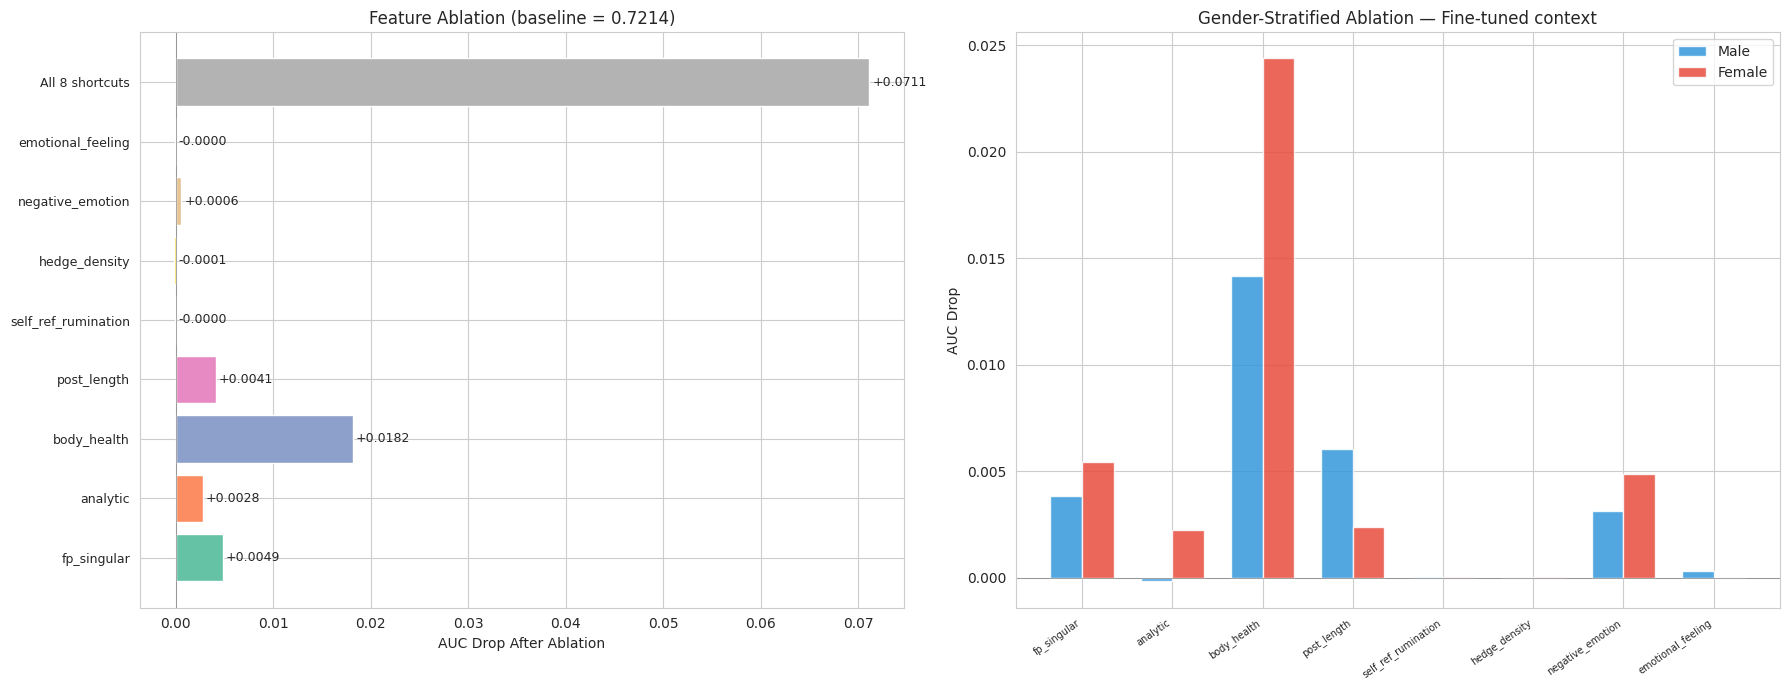

Saved → data/stage2_finetuned/ablation_analysis_finetuned.png


In [19]:
n_short = len(SHORTCUT_FEATURES)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

abl_labels = list(ablation_df['ablated']) + [f'All {n_short} shortcuts']
abl_drops  = list(ablation_df['AUC_drop']) + [drop_all]
cmap = plt.cm.Set2(np.linspace(0, 1, n_short + 1))
axes[0].barh(range(len(abl_labels)), abl_drops,
             color=[cmap[i] for i in range(len(abl_labels))], edgecolor='white')
axes[0].set_yticks(range(len(abl_labels))); axes[0].set_yticklabels(abl_labels, fontsize=9)
axes[0].set_xlabel('AUC Drop After Ablation')
axes[0].set_title(f'Feature Ablation (baseline = {baseline_auc:.4f})')
axes[0].axvline(0, color='grey', linewidth=0.5)
for i, d in enumerate(abl_drops):
    axes[0].text(max(d, 0)+0.0003, i, f'{d:+.4f}', va='center', fontsize=9)

x = np.arange(n_short); w = 0.35
male_drops   = strat_df[strat_df['gender']=='male'].set_index('ablated').loc[SHORTCUT_FEATURES, 'AUC_drop'].values
female_drops = strat_df[strat_df['gender']=='female'].set_index('ablated').loc[SHORTCUT_FEATURES, 'AUC_drop'].values
axes[1].bar(x-w/2, male_drops,   w, label='Male',   color='#3498db', alpha=0.85)
axes[1].bar(x+w/2, female_drops, w, label='Female', color='#e74c3c', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(SHORTCUT_FEATURES, fontsize=7, rotation=35, ha='right')
axes[1].set_ylabel('AUC Drop')
axes[1].set_title('Gender-Stratified Ablation — Fine-tuned context')
axes[1].legend(); axes[1].axhline(0, color='grey', linewidth=0.5)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/ablation_analysis_finetuned.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {OUT_DIR}/ablation_analysis_finetuned.png")

In [20]:
# ── Save all results ──────────────────────────────────────────────────────────
probe_df.to_csv(f'{OUT_DIR}/stage2b_probing_results.csv', index=False)
ablation_df.to_csv(f'{OUT_DIR}/stage2b_ablation_results.csv', index=False)
strat_df.to_csv(f'{OUT_DIR}/stage2b_gender_stratified_ablation.csv', index=False)
np.save(f'{OUT_DIR}/stage2b_shap_values.npy', shap_values)

print("=" * 60)
print("STAGE 2b SUMMARY — FINE-TUNED DistilRoBERTa")
print("=" * 60)

print(f"\n(A) PROBING — Fine-tuned [CLS] encoding of shortcuts & controls:")
for _, row in probe_df.iterrows():
    encoded = 'YES' if row['probe_AUC_median_split'] > 0.55 else 'weak/NO'
    tag = '★SHORTCUT' if row['role'] == 'shortcut' else '  control'
    print(f"  [{tag}] {row['feature']:25s}  AUC={row['probe_AUC_median_split']:.3f}  R²={row['probe_R2']:.4f}  → {encoded}")
print(f"  {'gender (m/f)':36s}  AUC={aucs_g.mean():.3f}")
print(f"  {'binary_label':36s}  AUC={aucs_l.mean():.3f}")

print(f"\n(B) SHAP — feature attribution ({len(SHORTCUT_FEATURES)}-shortcut logistic model):")
for feat, val in sorted(zip(SHORTCUT_FEATURES, mean_abs_shap), key=lambda x: -x[1]):
    pct = val / mean_abs_shap.sum() * 100
    print(f"  {feat:25s}  mean|SHAP|={val:.4f}  ({pct:.1f}%)")

print(f"\n(C) ABLATION — AUC impact of removing shortcuts:")
print(f"  Baseline (18 features): AUC = {baseline_auc:.4f}")
for _, row in ablation_df.iterrows():
    print(f"  Remove {row['ablated']:25s}: AUC = {row['AUC_after']:.4f}  (Δ = {row['AUC_drop']:+.4f})")
print(f"  Remove ALL {len(SHORTCUT_FEATURES)}:                  AUC = {abl_all_aucs.mean():.4f}  (Δ = {drop_all:+.4f})")

print(f"\n(D) GENDER-STRATIFIED ABLATION:")
for feat in SHORTCUT_FEATURES:
    m_drop = strat_df[(strat_df['ablated']==feat) & (strat_df['gender']=='male')]['AUC_drop'].values[0]
    f_drop = strat_df[(strat_df['ablated']==feat) & (strat_df['gender']=='female')]['AUC_drop'].values[0]
    asym = abs(m_drop - f_drop)
    bias_dir = '→ male' if m_drop > f_drop else '→ female'
    print(f"  {feat:25s}  male Δ={m_drop:+.4f}  female Δ={f_drop:+.4f}  asymmetry={asym:.4f} {bias_dir}")

print(f"\nSaved to: {OUT_DIR}/")

STAGE 2b SUMMARY — FINE-TUNED DistilRoBERTa

(A) PROBING — Fine-tuned [CLS] encoding of shortcuts & controls:
  [★SHORTCUT] fp_singular                AUC=0.954  R²=0.7756  → YES
  [★SHORTCUT] analytic                   AUC=0.886  R²=0.6033  → YES
  [★SHORTCUT] body_health                AUC=0.868  R²=0.6200  → YES
  [★SHORTCUT] post_length                AUC=0.995  R²=0.3802  → YES
  [★SHORTCUT] self_ref_rumination        AUC=0.892  R²=0.2947  → YES
  [★SHORTCUT] hedge_density              AUC=0.781  R²=0.3061  → YES
  [★SHORTCUT] negative_emotion           AUC=0.877  R²=0.2656  → YES
  [★SHORTCUT] emotional_feeling          AUC=0.820  R²=0.4107  → YES
  [  control] cogproc                    AUC=0.840  R²=0.5428  → YES
  [  control] clout                      AUC=0.894  R²=0.5505  → YES
  gender (m/f)                          AUC=0.984
  binary_label                          AUC=0.833

(B) SHAP — feature attribution (8-shortcut logistic model):
  analytic                   mean|SHAP|